- **[0] 모듈 로딩**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

- **[1] 데이터 준비**

In [2]:
df = pd.read_csv('../Data/Numbers/fish.csv')

# bream, smelt만
df = df[df['Species'].isin(['Bream', 'Smelt'])].reset_index(drop=True)
print(df['Species'].value_counts())
df.head()

Species
Bream    35
Smelt    14
Name: count, dtype: int64


,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


- **[2] 데이터 전처리**

In [3]:
df['Species'] = df['Species'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Species   49 non-null     category
 1   Weight    49 non-null     float64 
 2   Length    49 non-null     float64 
 3   Diagonal  49 non-null     float64 
 4   Height    49 non-null     float64 
 5   Width     49 non-null     float64 
dtypes: category(1), float64(5)
memory usage: 2.1 KB


- **[3] 학습용 | 테스트용 데이터셋 준비**

In [4]:
feature = df[['Width', 'Height', 'Weight']]
target  = df['Species']

x_train, x_test, y_train, y_test = train_test_split(
    feature,
    target,
    test_size=0.2,
    random_state=10,
    stratify=target
)

- **[4] 하이퍼파라미터 튜닝 및 교차 검증**
    * 모든 파라미터 조합 튜닝
    * 선택 파라미터 조합 튜닝
    * 2개 결과 비교

In [ ]:
k_model = KNeighborsClassifier()

param_dict = {
    'n_neighbors': range(1, 21, 2),
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}
# 전체 80개

skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# GridSearchCV
gs_model = GridSearchCV(
    k_model,
    param_grid=param_dict,
    cv=skFold,
    return_train_score=True,
    n_jobs=-1
)
gs_model.fit(x_train, y_train)

gs_best = gs_model.best_estimator_
print(f'GridSearchCV Best params: {gs_model.best_params_}')
print(f'GridSearchCV Best score : {gs_model.best_score_:.4f}')

GridSearchCV Best params: {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}
GridSearchCV Best score : 1.0000


In [ ]:
# RandomizedSearchCV
rs_model = RandomizedSearchCV(
    k_model,
    param_distributions=param_dict,
    cv=skFold,
    n_iter=40,
    random_state=10,
    return_train_score=True,
    n_jobs=-1
)
rs_model.fit(x_train, y_train)

rs_best = rs_model.best_estimator_
print(f'RandomizedSearchCV Best params: {rs_model.best_params_}')
print(f'RandomizedSearchCV Best score : {rs_model.best_score_:.4f}')

RandomizedSearchCV Best params: {'p': 2, 'n_neighbors': 1, 'algorithm': 'kd_tree'}
RandomizedSearchCV Best score : 1.0000


In [ ]:
# 결과 비교
print(f'GridSearchCV       best score: {gs_model.best_score_:.4f}')
print(f'RandomizedSearchCV best score: {rs_model.best_score_:.4f}')
print()
print(f'GridSearchCV       best params: {gs_model.best_params_}')
print(f'RandomizedSearchCV best params: {rs_model.best_params_}')

GridSearchCV       best score: 1.0000
RandomizedSearchCV best score: 1.0000

GridSearchCV       best params: {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}
RandomizedSearchCV best params: {'p': 2, 'n_neighbors': 1, 'algorithm': 'kd_tree'}


- **[5] 학습 결과 분석 및 시각화**

In [8]:
gs_cv = pd.DataFrame(gs_model.cv_results_)[['param_n_neighbors', 'mean_train_score', 'mean_test_score']]
rs_cv = pd.DataFrame(rs_model.cv_results_)[['param_n_neighbors', 'mean_train_score', 'mean_test_score']]

# GridSearchCV K별 평균
gs_totalDict = {'K': [], 'train_score': [], 'test_score': []}
for k in sorted(gs_cv['param_n_neighbors'].unique()):
    mask = gs_cv['param_n_neighbors'] == k
    gs_totalDict['K'].append(k)
    gs_totalDict['train_score'].append(gs_cv[mask]['mean_train_score'].mean())
    gs_totalDict['test_score'].append(gs_cv[mask]['mean_test_score'].mean())
gs_totalDF = pd.DataFrame(gs_totalDict)
gs_totalDF['Abs_Gap'] = abs(gs_totalDF['train_score'] - gs_totalDF['test_score'])

# RandomizedSearchCV K별 평균
rs_totalDict = {'K': [], 'train_score': [], 'test_score': []}
for k in sorted(rs_cv['param_n_neighbors'].unique()):
    mask = rs_cv['param_n_neighbors'] == k
    rs_totalDict['K'].append(k)
    rs_totalDict['train_score'].append(rs_cv[mask]['mean_train_score'].mean())
    rs_totalDict['test_score'].append(rs_cv[mask]['mean_test_score'].mean())
rs_totalDF = pd.DataFrame(rs_totalDict)
rs_totalDF['Abs_Gap'] = abs(rs_totalDF['train_score'] - rs_totalDF['test_score'])

# best K
gs_sortDF   = gs_totalDF.sort_values(by=['test_score', 'Abs_Gap'], ascending=[False, True], ignore_index=True)
rs_sortDF   = rs_totalDF.sort_values(by=['test_score', 'Abs_Gap'], ascending=[False, True], ignore_index=True)
gs_best_k, gs_best_score = gs_sortDF.iloc[0]['K'], gs_sortDF.iloc[0]['test_score']
rs_best_k, rs_best_score = rs_sortDF.iloc[0]['K'], rs_sortDF.iloc[0]['test_score']

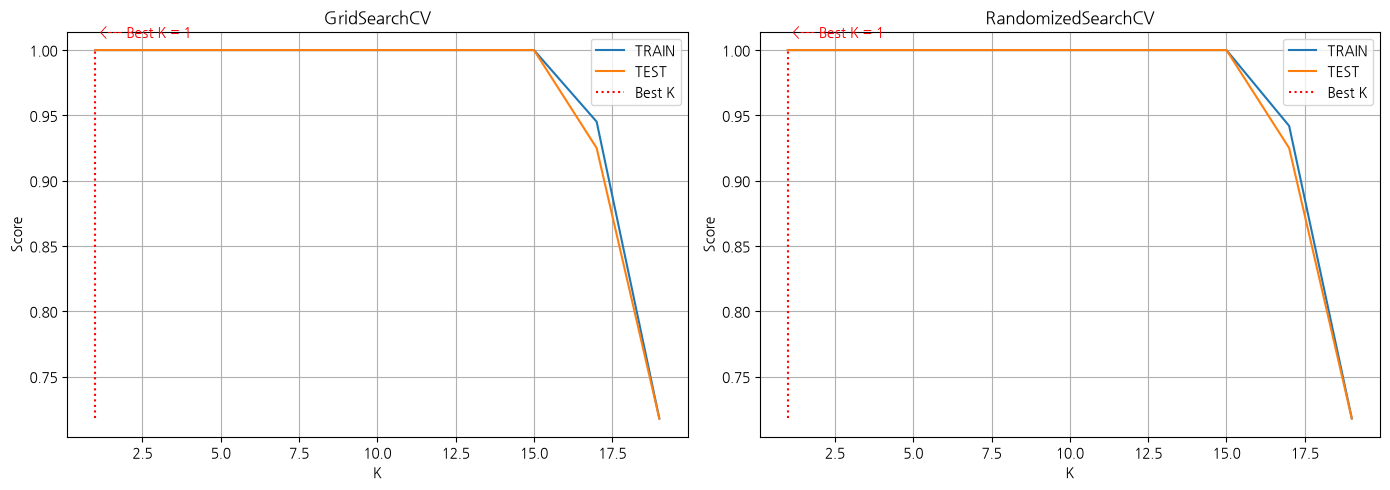

In [ ]:
# 시각화
# GridSearchCV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gs_totalDF['K'], gs_totalDF['train_score'], label='TRAIN')
axes[0].plot(gs_totalDF['K'], gs_totalDF['test_score'],  label='TEST')
axes[0].vlines(gs_best_k, gs_totalDF['train_score'].min(), gs_totalDF['train_score'].max(),
               colors='red', linestyles='dotted', label='Best K')
axes[0].text(gs_best_k, gs_best_score + 0.01, f' <--- Best K = {int(gs_best_k)}', c='red')
axes[0].set_title('GridSearchCV')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid()

# RandomizedSearchCV
axes[1].plot(rs_totalDF['K'], rs_totalDF['train_score'], label='TRAIN')
axes[1].plot(rs_totalDF['K'], rs_totalDF['test_score'],  label='TEST')
axes[1].vlines(rs_best_k, rs_totalDF['train_score'].min(), rs_totalDF['train_score'].max(),
               colors='red', linestyles='dotted', label='Best K')
axes[1].text(rs_best_k, rs_best_score + 0.01, f' <--- Best K = {int(rs_best_k)}', c='red')
axes[1].set_title('RandomizedSearchCV')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

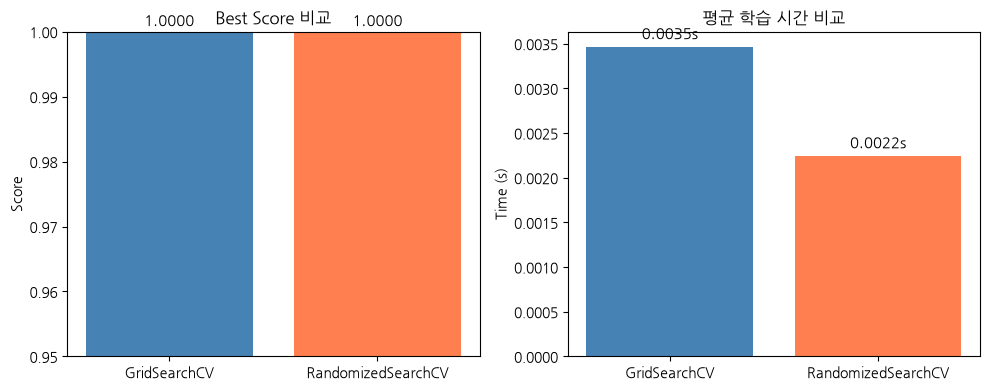

In [10]:
# GridSearchCV 와 RandomizedSearchCV 결과 비교 시각화
labels      = ['GridSearchCV', 'RandomizedSearchCV']
best_scores = [gs_model.best_score_, rs_model.best_score_]
fit_times   = [gs_cv['mean_fit_time'].mean() if 'mean_fit_time' in gs_cv.columns
               else pd.DataFrame(gs_model.cv_results_)['mean_fit_time'].mean(),
               pd.DataFrame(rs_model.cv_results_)['mean_fit_time'].mean()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, best_scores, color=['steelblue', 'coral'])
axes[0].set_ylim(min(best_scores) - 0.05, 1.0)
axes[0].set_title('Best Score 비교')
axes[0].set_ylabel('Score')
for i, v in enumerate(best_scores):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)

axes[1].bar(labels, fit_times, color=['steelblue', 'coral'])
axes[1].set_title('평균 학습 시간 비교')
axes[1].set_ylabel('Time (s)')
for i, v in enumerate(fit_times):
    axes[1].text(i, v + 0.0001, f'{v:.4f}s', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

- **[6] 예측 및 평가**
    * 테스트 데이터 기반 예측
    * 사용자 입력 기반 예측

In [ ]:
# 테스트 데이터 기반
y_pred = gs_best.predict(x_test)

print(f'정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))

# 이게맞는건가

정확도(Accuracy): 1.0000

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
       Smelt       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [12]:
# 사용자 입력 기반
# print(f'입력할 특성: {list(feature.columns)}  (예: 4.02 11.52 242.0)\n')

# user_input = input('물고기 정보 입력(너비 높이 무게): ').split()
# newDF = pd.DataFrame([[float(x) for x in user_input]], columns=feature.columns)

# y_pre = gs_best.predict(newDF)
# print(f'\n예측 결과: {y_pre[0]}')